In [13]:
!pip install torch torchvision matplotlib

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.bias = nn.Parameter(torch.zeros(out_features))

        # gates initialized near 0
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.1)

    def forward(self, x):
        gates = torch.sigmoid(5 * self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [17]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [18]:
def sparsity_loss(model):
    loss = 0
    count = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.mean(gates)
            count += 1
    return loss / count

In [19]:
def calculate_sparsity(model, threshold=0.3):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [20]:
def train_model(lambda_val):
    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(10):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            ce_loss = F.cross_entropy(outputs, labels)
            sp_loss = sparsity_loss(model)

            # amplified sparsity
            loss = ce_loss + lambda_val * sp_loss * 1000

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda {lambda_val} | Epoch {epoch+1} | Loss: {total_loss:.2f}")

    return model

In [21]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    sparsity = calculate_sparsity(model)

    return accuracy, sparsity

In [22]:
lambda_values = [1e-3, 1e-2, 1e-1]

results = []

for lam in lambda_values:
    print(f"\nTraining with lambda = {lam}")
    model = train_model(lam)
    acc, sp = evaluate(model)

    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sp:.2f}%")
    results.append((lam, acc, sp))


Training with lambda = 0.001
Lambda 0.001 | Epoch 1 | Loss: 1653.65
Lambda 0.001 | Epoch 2 | Loss: 1464.15
Lambda 0.001 | Epoch 3 | Loss: 1360.67
Lambda 0.001 | Epoch 4 | Loss: 1271.27
Lambda 0.001 | Epoch 5 | Loss: 1187.03
Lambda 0.001 | Epoch 6 | Loss: 1114.80
Lambda 0.001 | Epoch 7 | Loss: 1039.01
Lambda 0.001 | Epoch 8 | Loss: 963.92
Lambda 0.001 | Epoch 9 | Loss: 894.58
Lambda 0.001 | Epoch 10 | Loss: 826.87
Lambda: 0.001 | Accuracy: 55.08% | Sparsity: 1.03%

Training with lambda = 0.01
Lambda 0.01 | Epoch 1 | Loss: 5015.06
Lambda 0.01 | Epoch 2 | Loss: 4555.56
Lambda 0.01 | Epoch 3 | Loss: 4212.53
Lambda 0.01 | Epoch 4 | Loss: 3929.26
Lambda 0.01 | Epoch 5 | Loss: 3678.65
Lambda 0.01 | Epoch 6 | Loss: 3457.82
Lambda 0.01 | Epoch 7 | Loss: 3251.82
Lambda 0.01 | Epoch 8 | Loss: 3067.43
Lambda 0.01 | Epoch 9 | Loss: 2890.08
Lambda 0.01 | Epoch 10 | Loss: 2731.96
Lambda: 0.01 | Accuracy: 55.41% | Sparsity: 25.35%

Training with lambda = 0.1
Lambda 0.1 | Epoch 1 | Loss: 35619.43
Lamb

In [23]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity")
for r in results:
    print(f"{r[0]} | {r[1]:.2f}% | {r[2]:.2f}%")


Final Results:
Lambda | Accuracy | Sparsity
0.001 | 55.08% | 1.03%
0.01 | 55.41% | 25.35%
0.1 | 54.00% | 94.02%


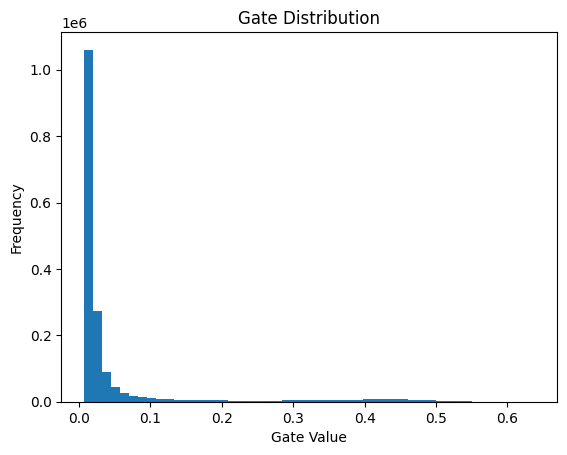

In [24]:
all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()